# JAX based BCDI phase retrieval

In [1]:
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.60"   # ~20 GiB on a 48 GiB A40

import jax
import jax.numpy as jnp
print(jax.devices())
import h5py

import numpy as np
import sys
import time 
import pynx
import cdiutils
import convexad_jax
from convexad_jax.optimize import *
from convexad_jax.viz import *
from convexad_jax.losses import _center_pad 
from convexad_jax.pynx_reconstruction import *
from scipy.fft import fftshift, ifftshift, fftn, ifftn


[CudaDevice(id=0)]


# Load data

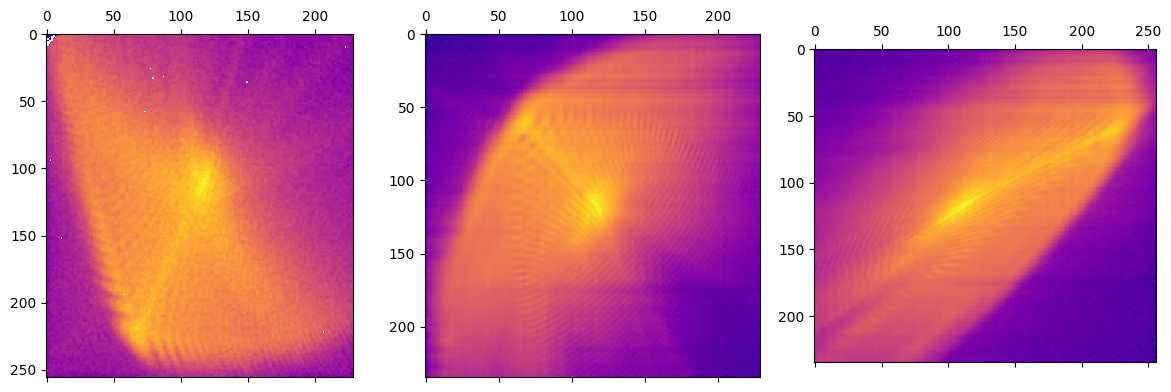

In [2]:
Iobs = np.load("../../ad_github/notebooks/data_prova.npz")["I"].astype(np.float32)
Iobs = np.load("../../paper/sim_tests/vary_phase_range/phase_range.npz")['Is'][9]

# Twins
# path = '../../twins/scan229_twin_20260120.npz'
# data = np.load(path)
# Iobs = data['I']

# # Concave
# filename = '/data/id01/inhouse/bellec/software/sharedipynb/Matteo/Detector_gap/3D_prediction/Matteo_tests/Jerome_Carnis/BCDI_reconstruction/preprocessed_data_s7/dataset_S2227_scan_2227.npz'
# file = np.load(filename)
# Iobs = file['data']

path = '/data/projects/id01ml/Codes/PhaseRetrieval/AutoDifferentiation/devels2026/pyramids/preprocessed_data/'
files = os.listdir(path)
data = np.load(path + files[1])
Iobs = data['data']
key = jax.random.PRNGKey(0)

plot_3D_projections(Iobs)

In [3]:
# Solve PR

In [ ]:
t0 = time.time()
result = reconstruct(
    key,
    Iobs,
    n_restarts = 12,
    N=10,
    size_factor=4.0,
    eps=1.5,
    alpha=0.0,
    beta=0.1,
    metric="mae",
    phase_type="displacement",
    phase_kwargs={'hkl': [2,2,2]},
    support_type="single",
    # support_kwargs={'M_parts': 3, 'N_per_part': 32},
    optimizer="adam",
    max_steps=3000,
    tol=1e-6,
    memory_size=10,
    learning_rate=0.05,
    grid_shape=None,
    stop_amplitude_grad=False,   # NEW
    n_adam_steps=800,            # NEW -- only used when optimizer="adam_gn"
    n_gn_steps=100,               # NEW -- only used when optimizer="adam_gn"
    lm_lambda0=1e-3,             # NEW -- only used when optimizer="adam_gn"
    cg_maxiter=100,
)
print(f"done in {time.time() - t0:.1f}s")

In [ ]:
# t0 = time.time()
# stage1_kwargs = dict(
#     N=64,                     # half-spaces per convex part
#     size_factor=4.0,
#     eps=0.6,                  # stage-1 support softness (unrelated to T_schedule)
#     alpha=0.0,                # support-size penalty weight
#     beta=0.01,                 # phase-TV penalty weight
#     metric="mae",             # or "poisson"
#     phase_type="displacement",        # or "phasor", "displacement"
#     phase_kwargs=None,       # e.g. {"Qnorm": ...} for phase_type="displacement"
#     support_kwargs=None,
#     optimizer="adam",         # or "lbfgs"
#     max_steps=500,
#     tol=1e-6,
#     memory_size=10,           # only used by optimizer="lbfgs"
#     learning_rate=0.05,       # only used by optimizer="adam"
#     decay_steps=500,
#     decay_rate=0.9,
#     staircase=True,
#     b1=0.9,
#     b2=0.98,
#     eps_adam=1e-6,
# )

# r1, r2 = reconstruct_two_stage(
#     key,
#     Iobs,
#     n_restarts_stage1 = 16,
#     stage1_support_type="single",
#     n_keep=1,
#     n_restarts_stage2=None,
#     grid_shape=None,
#     stage1_kwargs= stage1_kwargs,
#     T_schedule=(1.8, 0.9, 0.4),
#     zeta_schedule=(0.0001, 0.0000005, 0.0),
#     steps_per_stage=500,
#     gamma=1e-2,
#     delta=1e-2,
#     alpha2=1e-4,    
#     noise_scale_support=0.0,
#     noise_scale_phase=0.0,
#     stage2_learning_rate=0.02,
#     stage2_decay_steps=500,
#     stage2_decay_rate=0.9,
#     stage2_staircase=True,
#     stage2_b1=0.9,
#     stage2_b2=0.98,
#     stage2_eps_adam=1e-6,
#     tol=1e-6,
# )

# print(f"done in {time.time() - t0:.1f}s")

In [ ]:
print("best loss:", float(result.best_loss))
print("steps per restart:", result.all_steps)
# print("best loss 1:", float(r1.best_loss))
# print("best loss 2:", float(r2.best_loss))

# print("steps per restart 1:", r1.all_steps)
# print("steps per restart 2:", r2.all_steps)

In [ ]:
support, amplitude, phase = result.evaluate(Iobs)

modulus = amplitude*support
obj = modulus*phase[0] + 1.0j*modulus*phase[1]


In [ ]:
plot_2D_slices_middle_only_phase(obj, unwrap = False)
plot_2D_slices_middle_only_module(obj)

In [ ]:

obj_p = _center_pad(obj, Iobs.shape)
Icalc = np.abs(ifftshift(fftn(fftshift(obj_p))))
plot_3D_projections(Icalc)

# PyNX refinement

In [118]:
from pynx.processing_unit import ProcessingUnit
pu = ProcessingUnit()
pu.select_gpu(language="cuda", verbose=True)

Computing speed for available CUDA GPU [ranking by global memory bandwidth]:


MemoryError: cuMemAlloc failed: out of memory

In [ ]:
params = default_cdi_parameters()
params['obj_init'] = obj_p
params['support_threshold_relative'] = 0.25 # np.random.uniform(0.15,0.25)
params['support_update'] = 50
params['fix_support'] = False
params['algo_string'] = 'HIO_00 RAAR_00 ER_400'
params['support_update_border'] = True
params['support_update_border_n'] = 1
params['post_expand'] =(-1,1)
params['tv'] = 0.01
params['tv_er'] = 0.01
params['roi'] = 'full'
params['save_plot'] = False
params['plot_result']  = False

In [ ]:
obj3d, llk, support, return_dict = CDI_one_reconstruction(Iobs, params)
Icalc = np.abs(ifftshift(fftn(fftshift(obj3d))))**2
plot_2D_slices_middle_only_module_and_histogram(obj3d)
plot_2D_slices_middle_only_phase(obj3d, threshold_module= .25, unwrap= False)

In [ ]:
# np.savez('core_12_JAX_1.npz', obj = obj_p, data = Iobs)